<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [ ]:
# Проверяем версию CUDA
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [ ]:
from platform import python_version

print(python_version())

3.11.13


In [ ]:
pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers openpyxl datasets langchain-community ragatouille umap-learn matplotlib plotly sentencepiece pymorphy2

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 22.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 1.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 52.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 26.4 MB/

In [ ]:
!pip install pymorphy2

In [ ]:
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 93.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.1/103.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 96.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/

In [ ]:
!pip install langchain==0.1.20  # Или любая версия < 0.2.0
!pip install ragatouille

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.1/303.1 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: tenacity
    Found existing installation: tenacity 9.1.2
    Uninstalling tenacity-9.1.2:
      Successfully uninstalled tenacity-9.1.2
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.4.8
    Uninstalling langsmith-0.4.8:
      Successfully uninstalled langsmith-0.4.8
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.80
    Uninstalling l

In [ ]:
from ragatouille import RAGPretrainedModel

/tmp/ipykernel_47/1359710474.py:1: UserWarning: 
********************************************************************************
RAGatouille WARNING: Future Release Notice
--------------------------------------------
RAGatouille version 0.0.10 will be migrating to a PyLate backend 
instead of the current Stanford ColBERT backend.
PyLate is a fully mature, feature-equivalent backend, that greatly facilitates compatibility.
However, please pin version <0.0.10 if you require the Stanford ColBERT backend.
********************************************************************************
  from ragatouille import RAGPretrainedModel
2025-12-01 18:02:48.531456: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764612168.934092      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has alrea

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [ ]:
import gdown
import os
import random
import re
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from typing import Optional, List, Tuple, Union
import matplotlib.pyplot as plt

import base64
import requests
from PIL import Image
import PIL
from io import BytesIO

import re
import string
import nltk
import pymorphy2
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import torch
from transformers import pipeline
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer

from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document as LangchainDocument
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
from ragatouille import RAGPretrainedModel
from transformers import Pipeline

from sklearn.decomposition import PCA
import umap

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
!nvidia-smi
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

Mon Dec  1 18:03:26 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

'cuda'

In [ ]:
SEED = 42

def seed_torch(seed:int=42):
    """
    Функция для фиксации воспроизведения расчетов
        seed:int - параметр фиксации
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you are using multi-GPU.
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

In [ ]:
seed_torch(SEED)

In [ ]:
russian_stop_words = stopwords.words('russian')
english_stop_words = stopwords.words('english')

## Загрузка данных (4 балла)

In [ ]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=300b8434-ba91-4028-81da-2b0554c31fa8
To: /kaggle/working/file.csv
100%|██████████| 672M/672M [00:06<00:00, 105MB/s]  


## EDA
### Первичный анализ

In [ ]:
df = data.copy()

**Напишем функцию для первичного анализа количественных и качественных признаков**

In [ ]:
def check_data(df):
    print('\033[1m' + 'Изучим исходные данные' + '\033[0m')
    print(df.info())

    missed_cells = df.isna().sum().sum()/(df.shape[0]*(df.shape[1]-1))
    missed_rows = sum(df.isna().sum(axis=1)>0)/df.shape[0]
    print('\033[1m' + '\nПроверка пропусков' + '\033[0m')
    print('Количество пропусков: {:.0f}'.format(df.isna().sum().sum()))
    print('Количество пропусков в каждом столбце')
    display(df.isna().sum())
    print('Доля пропусков: {:.1%}'.format(missed_cells) + '\033[0m')
    print('Доля строк содержащих пропуски: {:.1%}'.format(missed_rows))

    ## Проверим дубликаты
    print('\033[1m' + '\nПроверка на дубликаты' + '\033[0m')
    print('Количество полных дубликатов: ', df.duplicated().sum())

    ## Посмотрим на сами данные
    print('\033[1m' + '\nПервые пять строк датасета:' + '\033[0m')
    display(df.head())

    print('\033[1m' + '\nОписание количественных данных:' + '\033[0m')
    if True in (df.dtypes == float).tolist():
        display(df.describe(include='float64').T)
    elif True in (df.dtypes == int).tolist():
        display(df.describe(include='int64').T)
    else:
        print('количественные данные отсутствуют')

    print('\033[1m' + '\nОписание категориальных данных:' + '\033[0m')
    # Исключаем колонку 'image' из обработки как категориального признака
    object_columns = [col for col in df.select_dtypes(include='object').columns if col != 'image']
    if object_columns:
        display(df[object_columns].describe(include='object').T)
    else:
        print('категориальные данные отсутствуют')

    print('\033[1m' + '\nВывод уникальных значений по каждому категориальному признаку:' + '\033[0m')
    # Исключаем колонку 'image' из вывода уникальных значений
    df_object = [col for col in df.select_dtypes(include='object').columns if col != 'image']

    for i in df_object:
        print('\033[1m' + '_' + str(i) + '\033[0m')
        display(df[i].value_counts())

In [ ]:
check_data(df)

Изучим исходные данные
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14634 entries, 0 to 14633
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   14634 non-null  int64  
 1   Name         14634 non-null  object 
 2   WikiData     12078 non-null  object 
 3   City         14634 non-null  object 
 4   Lon          14634 non-null  float64
 5   Lat          14634 non-null  float64
 6   description  12078 non-null  object 
 7   image        14634 non-null  object 
 8   en_txt       14634 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 1.0+ MB
None

Проверка пропусков
Количество пропусков: 5112
Количество пропусков в каждом столбце


,0
Unnamed: 0,0
Name,0
WikiData,2556
City,0
Lon,0
Lat,0
description,2556
image,0
en_txt,0


Доля пропусков: 4.4%
Доля строк содержащих пропуски: 17.5%

Проверка на дубликаты
Количество полных дубликатов:  0

Первые пять строк датасета:


,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...



Описание количественных данных:


...

,count
City,
Ярославль,4372
Владимир,3511
Нижний Новгород,3469
Екатеринбург,3282


_description


,count
description,
Православный храм в Ярославле,605
круглая башня Нижегородского кремля,288
здание в Екатеринбурге,287
музей в Екатеринбурге,285
памятник в Екатеринбурге,204
...,...
Владимирский государственный гуманитарный университет,27
Здание присутственных мест,27
Ярославское художественное училище,27


_en_txt


,count
en_txt,
arafed view of a large white building with gold domes,83
there is a large building with a clock on the top of it,78
arafed view of a large white building with a golden dome,66
arafed view of a large white building with green domes,56
there is a large building with a clock on the front of it,52
...,...
arafed building with a sign that says dom coberte on it,1
arafed photo of a building with a lot of windows and a street,1
arafed photograph of a building with a lot of windows and people walking around,1


**Ключевые наблюдения по сырым данным:**
- В датасете представлены 4 города и 387 уникальных достопримечательностей.
- Обнаружено 245 экстремально коротких описаний, а также дубликаты в сгенерированных англоязычных текстах (BLIP).
- Пропуски в колонках `WikiData` и `description` полностью совпадают по количеству.


---

**План действий**: Данные сильно зашумлены и содержат много смысловых дублей. Нам предстоит серьезная очистка и агрегация. Более того, для качественного RAG текущих описаний недостаточно, поэтому мы будем обогащать контекст, используя идентификаторы Wikidata.


---

Теперь посмотрим на **статистики количества слов в текстах**

In [ ]:
df['description_words'] = df['description'].fillna('').astype(str).apply(lambda x: len(x.split()))
df['en_txt_words'] = df['en_txt'].fillna('').astype(str).apply(lambda x: len(x.split()))

print("\nКоличество слов в description:")
print(df['description_words'].describe())

print("\nКоличество слов в en_txt:")
print(df['en_txt_words'].describe())

# проверка на очень короткие тексты
print("="*50)
short_desc = df[df['description_words'] < 3]
short_en = df[df['en_txt_words'] < 3]

print(f"Очень коротких description (< 3 слов): {len(short_desc)}")
print(f"Очень коротких en_txt (< 3 слов): {len(short_en)}")


Количество слов в description:
count    14634.000000
mean         3.371669
std          2.678743
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         30.000000
Name: description_words, dtype: float64

Количество слов в en_txt:
count    14634.000000
mean        12.029520
std          1.617982
min          1.000000
25%         11.000000
50%         12.000000
75%         13.000000
max         19.000000
Name: en_txt_words, dtype: float64
Очень коротких description (< 3 слов): 3970
Очень коротких en_txt (< 3 слов): 1


**Анализ длин текстов выявил следующее:**
- Русскоязычные `description` крайне скудны: 75% из них не превышают 4 слов, а почти треть датасета — это тексты короче 3 слов (или вообще пропуски).
- Англоязычные `en_txt` объемнее, но нужно помнить, что это машинная генерация (BLIP), которая может содержать галлюцинации.


---

**Подготовка к агрегации**: Поскольку в разных городах могут встречаться одноименные объекты, группировать данные только по названию нельзя. Для корректной идентификации создадим уникальный ключ `place_id`, объединив колонки `City` и `Name`.

In [ ]:
df['place_id'] = df['City'] + ' | ' + df['Name']
place_stats = df['place_id'].value_counts()
print(f"Всего уникальных мест: {len(place_stats)}")
print(f"Мест с одной записью: {(place_stats == 1).sum()}")
print(f"Мест с несколькими фото: {(place_stats > 1).sum()}")
print(f"Среднее количество фото на место: {place_stats.mean():.2f}")

Всего уникальных мест: 391
Мест с одной записью: 0
Мест с несколькими фото: 391
Среднее количество фото на место: 37.43


In [ ]:
df['place_id'].sample(4)

2360     Екатеринбург | Доходный дом купца Чувильдина
6561             Нижний Новгород | Дом И. Н. Соболева
12170                  Ярославль | Николая Чудотворца
8874                                 Владимир | Бобёр
Name: place_id, dtype: object

**Выводы из EDA**

1. **Объем данных**: Из почти 15 тысяч записей (14 634) уникальных локаций всего 391.

2. **Проблемы с полнотой**: Около 17.5% данных (2 556 строк) не имеют описаний и ссылок на WikiData. Это существенная потеря метаданных.

3. **Качество текстов**: Русскоязычные `description` критически малы (в среднем 3 слова). Английские `en_txt` от модели BLIP длиннее (~12 слов), но страдают от "синтетического шума" и артефактов.

4. **Выбросы**: В названиях и подписях присутствует откровенный мусор и нерелевантные объекты.

5. **Дублирование**: Полных дубликатов строк нет, так как к одному памятнику привязано множество разных фотографий. Решение — агрегация всех медиа и текстов вокруг созданного нами `place_id`.

---
**Для создания базы знаний, к который будет обращать Ретривер, необходимо будет очистить и обогатить наши данные**!

**Декодирование изображений**

Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [ ]:
def get_image(data):
    image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
    return image

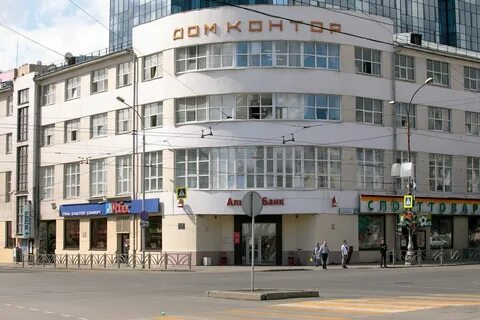

In [ ]:
get_image(df.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

### Предобработка данных

**Стратегия очистки: TF-IDF и поиск аномалий**

- Напишем функцию для расчета TF-IDF весов слов. В качестве корпуса возьмем склеенные русские и английские описания.
- Поскольку наша цель — отобрать топ-100 самых информативных записей, такой "двуязычный" TF-IDF отлично справится с грубой фильтрацией: он подсветит тексты с релевантной архитектурной и туристической лексикой. (Кстати, для финальных эмбеддингов мы тоже будем использовать мультиязычную модель).
- Дополнительно составим список стоп-паттернов (реклама, личные селфи, соцсети), чтобы исключить нерелевантные объекты (out-of-domain data).

In [ ]:
def explore_tfidf_anomalies(df):
    """
    Исследование аномалий в данных через TF-IDF без очистки
    """
    df_analysis = df.copy()
    df_analysis['combined_text'] = df_analysis['description'].fillna('') + ' ' + df_analysis['en_txt']
    # предобработка текста
    def preprocess_text(text):
        text = str(text).lower()
        text = re.sub(r'[^\w\s]', ' ', text)
        text = re.sub(r'\d+', '', text)
        text = ' '.join(text.split())
        return text

    df_analysis['clean_text'] = df_analysis['combined_text'].apply(preprocess_text)
    russian_stop_words = stopwords.words('russian')
    english_stop_words = stopwords.words('english')
    stop_words = english_stop_words + russian_stop_words
    # TF-IDF
    vectorizer = TfidfVectorizer(
        # ngram_range=(1, 2),
        max_features=1000,
        min_df=2,
        max_df=0.85,
        stop_words=stop_words
    )
    tfidf_matrix = vectorizer.fit_transform(df_analysis['clean_text'])

    # Анализируем значимость слов
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = tfidf_matrix.mean(axis=0).A1

    important_words = sorted(zip(feature_names, tfidf_scores), key=lambda x: x[1], reverse=True)

    print("📝 САМЫЕ ВАЖНЫЕ СЛОВА:")
    for i, (word, score) in enumerate(important_words[:30], 1):
        print(f"   {i:2d}. {word:15s} - {score:.4f}")

    print("\n📝 НАИМЕНЕЕ ВАЖНЫЕ СЛОВА:")
    for i, (word, score) in enumerate(important_words[-10:], 1):
        print(f"   {i:2d}. {word:15s} - {score:.4f}")

    # вычисляем TF-IDF стат. характеристики
    tfidf_dense = tfidf_matrix.toarray()
    df_analysis['tfidf_mean'] = np.mean(tfidf_dense, axis=1)
    df_analysis['tfidf_std'] = np.std(tfidf_dense, axis=1)
    df_analysis['tfidf_max'] = np.max(tfidf_dense, axis=1)
    df_analysis['tfidf_sum'] = np.sum(tfidf_dense, axis=1)

    # анализ распределения TF-IDF
    print("\nРаспределение TF-IDF scores:")
    print(df_analysis[['tfidf_mean', 'tfidf_std', 'tfidf_max', 'tfidf_sum']].describe())

    # поиск потенциальных аномалий по квантилям
    low_tfidf = df_analysis['tfidf_mean'] < df_analysis['tfidf_mean'].quantile(0.05)
    high_tfidf = df_analysis['tfidf_mean'] > df_analysis['tfidf_mean'].quantile(0.95)

    print(f"\nЗаписей с очень низким TF-IDF (<5%): {low_tfidf.sum()}")
    print(f"Записей с очень высоким TF-IDF (>95%): {high_tfidf.sum()}")

    # анализ подозрительных фичей / паттернов
    suspicious_patterns = [
        # Мемы и соцсети
        'meme', 'instagram', 'tiktok', 'profile',
        # Реклама и коммерция
        'advertisement', 'promo', 'sponsored', 'commercial', 'shop', 'store', 'sale', 'buy', 'discount',
        # Личные фото и события
        'personal', 'selfie', 'portrait', 'me', 'party',
        # повседневные объекты
        'banner', 'poster', 'billboard']

    def contains_suspicious_patterns(text):
        return any(pattern in text for pattern in suspicious_patterns)

    df_analysis['suspicious_pattern'] = df_analysis['clean_text'].apply(contains_suspicious_patterns)

    print(f"\n🔍 Записей с подозрительными паттернами: {df_analysis['suspicious_pattern'].sum()}")

    print("\n📋 Категории потенциальных проблем:")

    # Низкий TF-IDF
    low_tfidf_samples = df_analysis[low_tfidf].sample(5)
    print(f"\nНизкий TF-IDF:")
    for idx, row in low_tfidf_samples.iterrows():
        print(f"   - {row['Name']} | {row['City']}")
        print(f"     TF-IDF: {row['tfidf_mean']:.4f} | '{row['description'][:50] if pd.notna(row['description']) else row['en_txt'][:300]}...'")

    # Высокий TF-IDF
    high_tfidf_samples = df_analysis[high_tfidf].sample(5)
    print(f"\nВысокий TF-IDF:")
    for idx, row in high_tfidf_samples.iterrows():
        print(f"   - {row['Name']} | {row['City']}")
        print(f"     TF-IDF: {row['tfidf_mean']:.4f} | '{row['description'][:50] if pd.notna(row['description']) else row['en_txt'][:300]}...'")

    # Подозрительные паттерны
    suspicious_samples = df_analysis[df_analysis['suspicious_pattern']].sample(5)
    print(f"\n🚨")
    for idx, row in suspicious_samples.iterrows():
        print(f"   - {row['Name']} | {row['City']}")
        print(f"     Текст: '{row['clean_text'][:300]}...'")

    # 10. Сводная статистика
    print(f"\n📊 Общий отчет:")
    total_problems = (low_tfidf | high_tfidf | df_analysis['suspicious_pattern']).sum()
    print(f"Всего потенциальных проблемных записей: {total_problems}")
    print(f"Доля от общего числа: {total_problems/len(df):.1%}")

    return df_analysis

In [ ]:
df_analysis = explore_tfidf_anomalies(df)

📝 САМЫЕ ВАЖНЫЕ СЛОВА:
    1. building        - 0.0662
    2. arafed          - 0.0632
    3. large           - 0.0430
    4. view            - 0.0424
    5. clock           - 0.0403
    6. white           - 0.0386
    7. ярославле       - 0.0384
    8. church          - 0.0372
    9. front           - 0.0371
   10. екатеринбурге   - 0.0367
   11. tower           - 0.0352
   12. green           - 0.0345
   13. top             - 0.0324
   14. храм            - 0.0291
   15. man             - 0.0289
   16. roof            - 0.0256
   17. православный    - 0.0236
   18. statue          - 0.0235
   19. steeple         - 0.0225
   20. памятник        - 0.0214
   21. dome            - 0.0206
   22. музей           - 0.0193
   23. церковь         - 0.0193
   24. people          - 0.0176
   25. standing        - 0.0174
   26. park            - 0.0172
   27. дом             - 0.0170
   28. domes           - 0.0169
   29. city            - 0.0166
   30. здание          - 0.0163

📝 НАИМЕНЕЕ ВАЖНЫЕ

**Выводы по результатам TF-IDF анализа:**

1. В целом, TF-IDF отлично справляется с выделением доменной лексики: топ-30 слов с максимальным весом (архитектура, памятники) ярко контрастируют с фоновыми словами и незначимыми деталями окружения.

2. Однако суммарный скор TF-IDF для всей строки оказался нестабильным критерием. Короткая строка может быть максимально релевантной, а длинная — набрать высокий балл просто за счет объема слов, оставаясь при этом "шумной".

3. Жесткая негативная фильтрация (поиск нецелевых слов/мусора) также показала себя как недостаточно надежный метод, дающий ложные срабатывания.

4. Выявлен явный артефакт генерации модели BLIP — слово "arafed", которое получает необоснованно высокий TF-IDF вес. Его необходимо удалить регулярными выражениями.

---

Учтем эти наблюдения при очистке датасета.

**Подготовка данных для RAG-системы**

Реализуем пайплайн предобработки, который последовательно выполнит следующие шаги:

а) **Агрегация и нормализация**: очистим текст от артефактов и сгруппируем все записи по `place_id`. Для каждого уникального места выберем самое длинное и информативное текстовое описание из доступных.

б)  **Фильтрация шума**: применим комбинированный подход — отсечем 10% записей с наихудшим скором TF-IDF (статистический фильтр), а оставшиеся проверим на наличие обязательных ключевых слов нашей предметной области (семантический фильтр).


в) **Сэмплирование**: для тестирования пайплайна сформируем стратифицированную выборку из 100 чистых объектов, сохранив пропорции по городам.

In [ ]:
!pip install  natasha

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 50.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.6 MB/s eta 0:00:00
  Created wheel for intervaltree: filename=intervaltree-3.1.0-py2.py3-none-any.whl size=26190 sha256=5bd3dfe28a51cdf04e262df9b21345119b1eacad3a4034e1a8e2ef8682881202
  Stored in directory: /root/.cache/pip/wheels/31/d7/d9/eec6891f78cac19a693bd40ecb8365d2f4613318c145ec9816
Successfully built intervaltree


In [ ]:
from natasha import MorphVocab

In [ ]:
print("\n[1/3] Агрегация дубликатов по place_id...")
# Копируем исходный датафрейм
df_work = df.copy()

# Нормализация текстов
def normalize_text(s):
    # Проверка на NaN или нестроковый тип
    if pd.isna(s) or not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r"\barafed\b", "", s)  # удаляем артефакт BLIP
    s = re.sub(r"\s+", " ", s).strip()
    return s

df_work['description_clean'] = df_work['description'].apply(normalize_text)
df_work['en_txt_clean'] = df_work['en_txt'].apply(normalize_text)

# Агрегация по place_id
def aggregate_place(group):
    # Выбираем самое длинное description из имеющихся в группе
    best_desc = group['description_clean'].fillna('').astype(str)
    best_desc = best_desc[best_desc.str.len() > 0]
    if len(best_desc) > 0:
        best_text = best_desc.iloc[best_desc.str.len().argmax()]
    else:
        best_text = ""

    # Конкатенируем уникальные en_txt (макс 3)
    unique_en = group['en_txt_clean'].fillna('').astype(str).unique()
    unique_en = [e for e in unique_en if len(e) > 10][:3]  # топ-3
    concat_text = " | ".join(unique_en)

    # Собираем все изображения
    images = group['image'].tolist()

    return pd.Series({
        'City': group['City'].iloc[0],
        'Name': group['Name'].iloc[0],
        'Lon': group['Lon'].iloc[0],
        'Lat': group['Lat'].iloc[0],
        'WikiData': group['WikiData'].iloc[0] if pd.notna(group['WikiData'].iloc[0]) else None,
        'best_text': best_text,
        'concat_text': concat_text,
        'images': images,
        'photo_count': len(group)
    })

df_aggregated = df_work.groupby('place_id', as_index=False).apply(aggregate_place).reset_index(drop=True)

print(f"Исходных записей: {len(df_work)}")
print(f"Уникальных мест после агрегации: {len(df_aggregated)}")


[1/3] Агрегация дубликатов по place_id...
Исходных записей: 14634
Уникальных мест после агрегации: 391


In [ ]:
df_aggregated.shape

(391, 10)

In [ ]:
print("\n[2/3] TF-IDF фильтрация выбросов + фильтрация по целевым словам...")

# Комбинированный текст
df_aggregated['combined'] = (df_aggregated['best_text'].fillna('') + ' ' +
                               df_aggregated['concat_text'].fillna('')).str.strip()

# Подсчет слов
df_aggregated['combined_wc'] = df_aggregated['combined'].apply(lambda x: len(x.split()) if x else 0)
df_aggregated['best_wc'] = df_aggregated['best_text'].apply(lambda x: len(x.split()) if x else 0)

# stop_words
russian_stop_words = stopwords.words('russian')
english_stop_words = stopwords.words('english')
stop_words = english_stop_words + russian_stop_words
# TF-IDF
vectorizer = TfidfVectorizer(
    max_features=1000,
    min_df=2,
    max_df=0.85,
    stop_words=stop_words
)
tfidf_matrix = vectorizer.fit_transform(df_aggregated['combined'].replace('', 'empty'))
tfidf_sum = np.asarray(tfidf_matrix.sum(axis=1)).ravel()
df_aggregated['tfidf_sum'] = tfidf_sum

# 10% квантиль для фильтрации
low_threshold = np.quantile(tfidf_sum, 0.10)

# Проверка на ключевые термины
arch_keywords = {
    # Архитектура
    "building", "church", "cathedral", "museum", "monument", "tower", "bridge", "dome",
    "храм", "собор", "музей", "башня", "кремль", "здание", "дворец", "усадьба", "замок",
    # Природа
    "заповедник", "национальный парк", "озеро", "река", "водопад", "пещера", "гора", "остров",
    # Городские пространства
    "площадь", "набережная", "парк", "сквер", "бульвар", "мост",
    # Культурные объекты
    "галерея", "театр", "филармония", "обсерватория", "планетарий",
    # Мемориалы
    "памятник", "монумент", "мемориал", "обелиск",
    # Религия (доп.)
    "монастырь", "часовня", "мечеть", "синагога", "дацан",
    # История и археология
    "крепость", "городище", "раскоп", "курган",
    # Инфраструктура (туристическая)
    "маяк", "вокзал", "пристань", "телебашня"
}

morph = MorphVocab()
def has_arch_token(text):
    # Проверка на пустой/нестроковый ввод
    if not text or not isinstance(text, str):
        return False

    # Приводим текст к нижнему регистру и разбиваем на слова
    words = text.lower().split()

    # Лемматизируем каждое слово (берём наиболее вероятную лемму)
    lemmas = []
    for word in words:
        parsed = morph.parse(word)
        if parsed:  # если разбор удался
            lemmas.append(parsed[0].normal)  # добавляем нормальную форму


    # Проверяем наличие хотя бы одного ключевого слова среди лемм
    return any(kw in lemmas for kw in arch_keywords)

df_aggregated['has_arch'] = df_aggregated['combined'].apply(has_arch_token)

# условие жесткой фильтрации
df_clean = df_aggregated[
    (df_aggregated['tfidf_sum'] > low_threshold) &  # Не в нижних 10%
    (
        (df_aggregated['best_wc'] >= 4) |  # минимум 4 слова в описании
        df_aggregated['has_arch'] |         # или есть ключевые термины
        (df_aggregated['combined_wc'] >= 12) # Или хотя бы 12 слов суммарно
    )
].copy()

df_clean = df_clean.drop_duplicates('place_id').reset_index(drop=True)
print(f"Чистых мест после фильтрации: {len(df_clean)}")


[2/3] TF-IDF фильтрация выбросов + фильтрация по целевым словам...
Чистых мест после фильтрации: 351


In [ ]:
df_clean.shape

(351, 15)

In [ ]:
print("\n[3/3] Стратифицированная выборка...")

n_target = 100
city_counts = df_clean['City'].value_counts()

# Пропорциональное распределение по городам
samples_list = []
np.random.seed(42)

for city, count in city_counts.items():
    proportion = count / len(df_clean)
    n_samples = max(1, int(np.round(proportion * n_target)))

    city_data = df_clean[df_clean['City'] == city]
    n_actual = min(n_samples, len(city_data))

    sampled = city_data.sample(n=n_actual, random_state=42)
    samples_list.append(sampled)

samples_df = pd.concat(samples_list).drop_duplicates('place_id')

# Добираем до 100 если нужно
if len(samples_df) < n_target:
    remaining = n_target - len(samples_df)
    pool = df_clean[~df_clean['place_id'].isin(samples_df['place_id'])]
    extra = pool.sample(n=min(remaining, len(pool)), random_state=42)
    samples_df = pd.concat([samples_df, extra]).drop_duplicates('place_id')

samples_df = samples_df.reset_index(drop=True)


[3/3] Стратифицированная выборка...


**Подготовка итоговых данных для датасета**

Сформируем финальные колонки, которые будут использоваться RAG-системой:
- `sample_text` — комбинированный текст, объединяющий русскоязычное описание объекта и его визуальные признаки на английском языке.
- `images_meta` — массив (список) с закодированными изображениями локации.

In [ ]:
def build_sample_text(row):
    return f"{row['best_text']} | Visual: {row['concat_text']}"

samples_df['sample_text'] = samples_df.apply(build_sample_text, axis=1)
samples_df['images_meta'] = samples_df['images'].apply(lambda x: x if isinstance(x, list) else [])

rag_dataset = samples_df[[
    'place_id', 'City', 'Name', 'sample_text', 'images_meta',
    'Lon', 'Lat', 'tfidf_sum', 'has_arch', 'photo_count'
]].copy()

In [ ]:

print("✅ ПОДГОТОВКА ЗАВЕРШЕНА")
print("="*30)
print(f"📊 Итоговая выборка: {len(rag_dataset)} мест")
print(f"\n🏙️ Распределение по городам:")
print(rag_dataset['City'].value_counts())
print(f"\n📝 Статистика текстов:")
print(f"Средняя длина sample_text: {rag_dataset['sample_text'].apply(lambda x: len(x.split())).mean():.1f} слов")
print(f"Мест с архитектурными терминами: {rag_dataset['has_arch'].sum()}")

# Показываем примеры
print(f"\n🔍 Примеры из финального датасета:")
for idx, row in rag_dataset.head(3).iterrows():
    print(f"\n[{row['City']}] {row['Name']}")
    print(f"  Текст: {row['sample_text'][:150]}...")
    print(f"  Фото: {row['photo_count']}, TF-IDF: {row['tfidf_sum']:.3f}")

✅ ПОДГОТОВКА ЗАВЕРШЕНА
📊 Итоговая выборка: 100 мест

🏙️ Распределение по городам:
City
Нижний Новгород    27
Екатеринбург       26
Ярославль          26
Владимир           21
Name: count, dtype: int64

📝 Статистика текстов:
Средняя длина sample_text: 41.9 слов
Мест с архитектурными терминами: 94

🔍 Примеры из финального датасета:

[Нижний Новгород] Лицей № 82
  Текст: лицей № 82 "школа баррикад" | Visual: building with a large circular entrance and a green shield on the front | view of a building with a clock tower ...
  Фото: 28, TF-IDF: 3.717

[Нижний Новгород] Дом Сироткина
  Текст: памятник архитектуры нижнего новгорода, корпус художественного музея | Visual: there is a large white building with a balcony on the top of it | there...
  Фото: 32, TF-IDF: 3.436

[Нижний Новгород] Обелиск Минину и Пожарскому
  Текст: памятник в нижнем новгороде, россия | Visual: monument in the center of a park with a lake in the background | obelisk in a park with a view of a lake...
  Фото: 29, TF-ID

In [ ]:
rag_dataset.sample(2)

,place_id,City,Name,sample_text,images_meta,Lon,Lat,tfidf_sum,has_arch,photo_count
83,Владимир | Ивановский вал,Владимир,Ивановский вал,| Visual: there are many cars that are parked...,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,40.412052,56.13422,3.146776,True,29
53,Ярославль | Николая Чудотворца,Ярославль,Николая Чудотворца,храм в ярославле | Visual: church with green d...,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,39.865314,57.61031,3.187769,True,55


In [ ]:
rag_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   place_id     100 non-null    object 
 1   City         100 non-null    object 
 2   Name         100 non-null    object 
 3   sample_text  100 non-null    object 
 4   images_meta  100 non-null    object 
 5   Lon          100 non-null    float64
 6   Lat          100 non-null    float64
 7   tfidf_sum    100 non-null    float64
 8   has_arch     100 non-null    bool   
 9   photo_count  100 non-null    int64  
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 7.3+ KB


**Обогащение данными из Википедии**

In [ ]:
!pip install wikipedia

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11757 sha256=667c7c8320cbaa270650af46e0c60ff8368975db85417a367c4a6aa892d39bef
  Stored in directory: /root/.cache/pip/wheels/8f/ab/cb/45ccc40522d3a1c41e1d2ad53b8f33a62f394011ec38cd71c6
Successfully built wikipedia


In [ ]:
import wikipedia
from tqdm.auto import tqdm

wikipedia.set_lang("ru")

def fetch_wikipedia_summary(row):
    """
    Ищет статью в Википедии по Названию + Городу.
    Возвращает summary или None.
    """
    query = f"{row['Name']} {row['City']}"

    try:
        search_results = wikipedia.search(query)
        if not search_results:
            return None

        # Берем первый результат
        page = wikipedia.page(search_results[0], auto_suggest=False)
        return page.summary

    except (wikipedia.DisambiguationError, wikipedia.PageError, Exception):
        return None

In [ ]:
tqdm.pandas(desc="Wiki Fetch")
rag_dataset['wiki_content'] = rag_dataset.progress_apply(fetch_wikipedia_summary, axis=1)

Wiki Fetch:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
rag_dataset['wiki_content'].sample(2)

,wiki_content
98,"Владимир Львович Иванов (род. 25 июля 1967, Ря..."
4,Ни́жний Но́вгород (в разговорной речи часто Ни...


**Сборка гибридного контекста**

Для максимальной информативности каждый документ, подаваемый в модель, будет иметь строгую структуру:
1. **Объект:** Название достопримечательности.
2. **Локация:** Город.
3. **Историческая справка:** Данные, спарсенные из Википедии.
4. **Визуальное описание:** Подписи, сгенерированные моделью BLIP.

In [ ]:
def build_hybrid_context(row):
    """
    Собирает финальный контекст из:
    1. Имя, Город
    2. Факты (Wiki или best_text из sample_text)
    3. Визуал (concat_text из sample_text)
    """
    original_sample = str(row['sample_text'])

    if " | Visual: " in original_sample:
        parts = original_sample.split(" | Visual: ")
        old_ru_desc = parts[0].strip()
        visual_desc = parts[1].strip() if len(parts) > 1 else ""
    else:
        # если разделителя нет (например, concat_text был пуст)
        old_ru_desc = original_sample
        visual_desc = ""

    # Приоритет: Wiki > best_text на русском
    if pd.notna(row.get('wiki_content')) and len(str(row['wiki_content'])) > 20:
        fact_context = row['wiki_content']
    else:
        fact_context = old_ru_desc

    lines = [
        f"Объект: {row['Name']}",
        f"Локация: {row['City']}",
        f"Историческая справка: {fact_context}"
    ]

    if visual_desc:
        lines.append(f"Визуальное описание (Visual): {visual_desc}")

    return "\n".join(lines)

In [ ]:
rag_dataset['final_context'] = rag_dataset.apply(build_hybrid_context, axis=1)

In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)  # Убираем ограничение по ширине
rag_dataset['final_context'].sample(2)

,final_context
94,"Объект: Владимирское духовное училище\nЛокация: Владимир\nИсторическая справка: Влади́мир (др.-рус. Володимѣрь) — город в России, административный центр Владимирской области и городского округа город Владимир.\nИсторически известен как Владимир-на-Клязьме или Владимир-Залесский, в отличие от Владимира-Волынского.\nСуществует две летописные версии основания города, в 990 и в 1108 году. Археологические изыскания, проводящиеся во Владимире начиная с первой половины XX века, не подтверждают существования города в конце X века, поэтому в исследованиях археологов предпочтение отдано 1108 году. В XII—XIV веках — столица Великого княжества Владимирского.\nОдин из крупнейших туристических центров европейской части России. Входит в туристический маршрут «Золотое кольцо России».\nРасположен преимущественно на левом берегу реки Клязьмы, в 176 км к востоку от столицы России города Москвы. Транспортный узел на автомобильных («Волга» и «Восток») и железнодорожной (Нижегородский ход Транссиба) магистралях.\nПлощадь города — 137,014 км². Население — 341 579 чел. (2025).\nВизуальное описание (Visual): view of a street with a clock tower in the middle of it | there is a black and white photo of a building with a horse and carriage | yellow building with blue windows and a red door on a street"
40,"Объект: Уральский государственный технический университет\nЛокация: Екатеринбург\nИсторическая справка: Ура́льский госуда́рственный техни́ческий университе́т — УПИ́ и́мени Б. Н. Е́льцина (УГТУ-УПИ, до 1992 года — Уральский политехнический институт, до 2008 года носил имя С. М. Кирова) — высшее учебное заведение в Екатеринбурге. В 2010 году при объединении с Уральским государственным университетом им. А. М. Горького преобразован в Уральский федеральный университет.\nВизуальное описание (Visual): statue of a man in front of a building with columns | view of a building with a fountain in front of it | view of a city with a large building and a lot of trees"


In [ ]:
pd.reset_option('^display.', silent=True)
rag_dataset.sample(2)

,place_id,City,Name,sample_text,images_meta,Lon,Lat,tfidf_sum,has_arch,photo_count,wiki_content,final_context
79,Владимир | Белокаменные памятники Владимира и ...,Владимир,Белокаменные памятники Владимира и Суздаля,белокаменные памятники владимира и суздаля | V...,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,40.416698,56.150002,3.101994,True,29,Белока́менные па́мятники Влади́мира и Су́здаля...,Объект: Белокаменные памятники Владимира и Суз...
37,Екатеринбург | №19 Музей истории Екатеринбурга,Екатеринбург,№19 Музей истории Екатеринбурга,музей в екатеринбурге | Visual: there is a bui...,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,60.611122,56.840714,3.377052,True,27,Екатеринбу́рг (с 14 октября 1924 по 23 сентябр...,Объект: №19 Музей истории Екатеринбурга\nЛокац...


---

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

## Ретривер

In [ ]:

from tqdm.auto import tqdm
from typing import List, Optional

# LangChain и Transformers
from langchain.docstore.document import Document as LangchainDocument
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from transformers import AutoTokenizer

# Настройки
EMBEDDING_MODEL_NAME = "BAAI/bge-m3" # Мощный мультиязычный эмбеддер
CHROMA_PATH = "./chroma_db" # Куда сохранить векторную базу знаний

In [ ]:
from sentence_transformers import SentenceTransformer

# Чтобы получить значение max sequence_length, мы запросим базовый объект `SentenceTransformer`, используемый в RecursiveCharacterTextSplitter
print(f"Model's maximum sequence length: {SentenceTransformer('BAAI/bge-m3').max_seq_length}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Model's maximum sequence length: 8192


**Создание векторной базы знаний**
- Каждую запись датасета мы оборачиваем в стандартный объект `LangchainDocument`;
- Всю вспомогательную информацию (исходные изображения, город, точные GPS-координаты) мы сохраняем в словарь `metadata`. Это позволит нам красиво оформить финальный ответ гида, не засоряя сам текстовый эмбеддинг.

In [ ]:
RAW_KNOWLEDGE_BASE = []
METADATA_DELIMITER = " ||| " # Разделитель для склейки списка картинок

print("Упаковка документов для Chroma...")

for _, row in tqdm(rag_dataset.iterrows(), total=len(rag_dataset)):

    # Очистка метаданных картинок (List -> String)
    img_meta = row.get('images_meta', [])

    if isinstance(img_meta, list):
        # Фильтруем None и склеиваем в одну строку
        valid_imgs = [str(x) for x in img_meta if x]
        clean_images = METADATA_DELIMITER.join(valid_imgs)
    else:
        clean_images = str(img_meta) if pd.notna(img_meta) else ""

    # Создание документа
    doc = LangchainDocument(
        page_content=row['final_context'],
        metadata={
            "place_id": str(row['place_id']),
            "name": str(row['Name']),
            "city": str(row['City']),

            # картинки одной строкой
            "images_meta": clean_images,

            # Гео-данные (числа для фильтров, url для вывода)
            "lat": float(row['Lat']),
            "lon": float(row['Lon']),
            "maps_url": f"https://www.google.com/maps?q={row['Lat']},{row['Lon']}"
        }
    )
    RAW_KNOWLEDGE_BASE.append(doc)

print(f"Подготовлено {len(RAW_KNOWLEDGE_BASE)} документов.")

Упаковка документов для Chroma...


  0%|          | 0/100 [00:00<?, ?it/s]

Подготовлено 100 документов.


In [ ]:
print(f"Пример обработанного текста:\n---\n{RAW_KNOWLEDGE_BASE[0].page_content}\n---")


Пример обработанного текста:
---
Объект: Лицей № 82
Локация: Нижний Новгород
Историческая справка: Лицей № 82 — лицей в Сормовском районе Нижнего Новгорода. Наибольшую известность получил как «Школа баррикад» после революции 1905 года.
Визуальное описание (Visual): building with a large circular entrance and a green shield on the front | view of a building with a clock tower in front of it | a red and yellow owl sitting on top of a wooden sticker
---


**Посмотрим на фотографии для объекта из Лицея № 82 из Нижнего Новгорода**

In [ ]:
import io

=== Лицей № 82 (Нижний Новгород) ===
Всего фото (meta): 28
Тип данных: LIST (Pandas style)
Готово к отображению: 28 фото. Показываем первые 10...


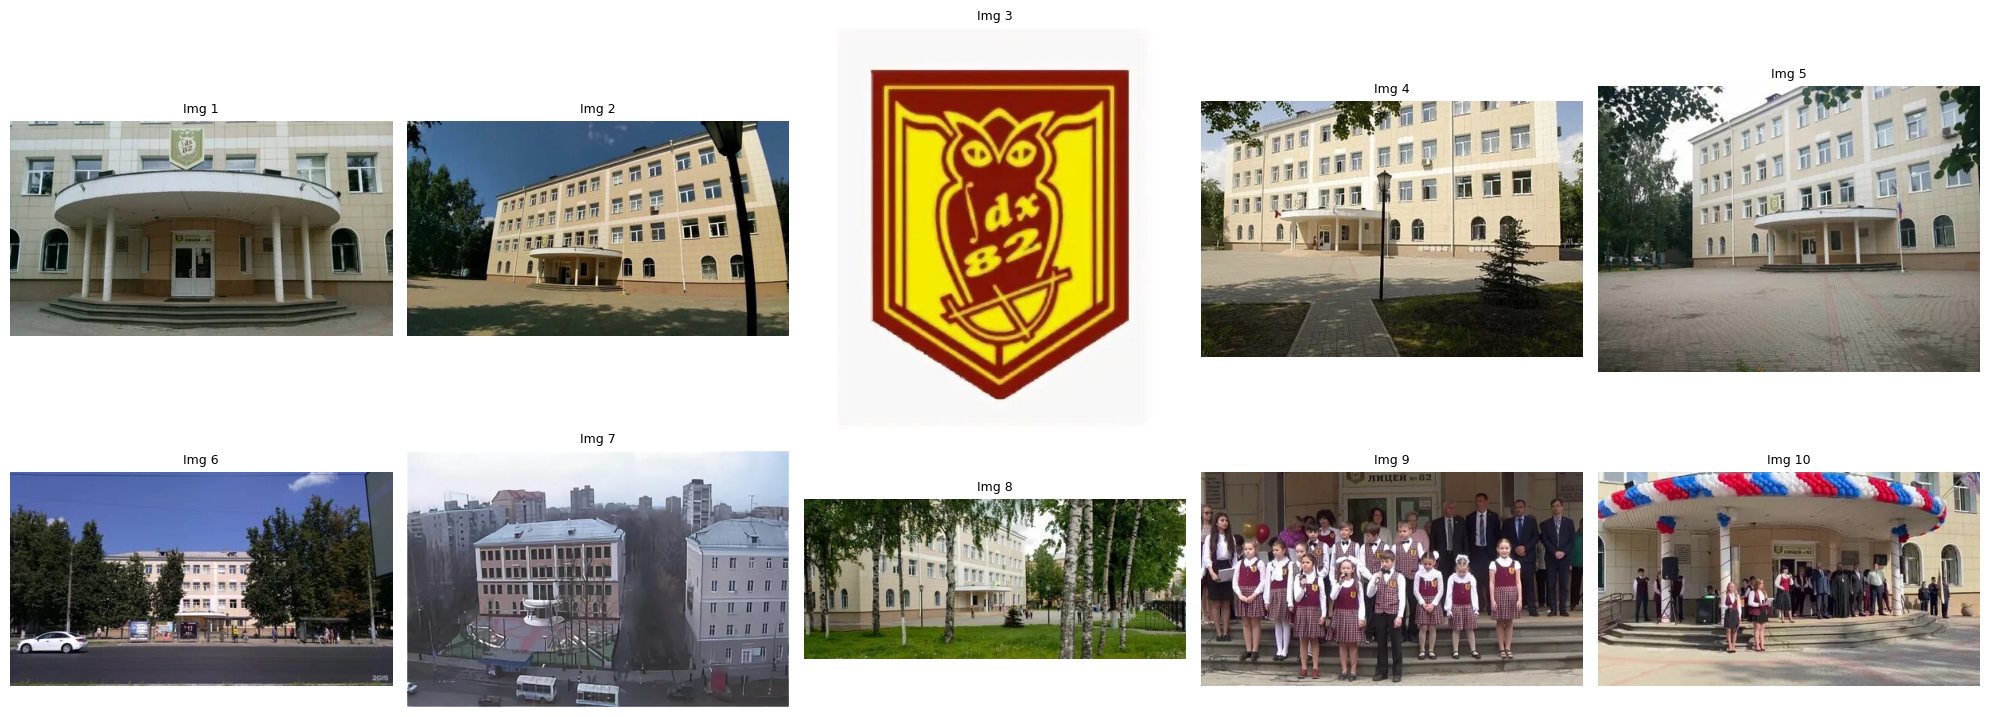

In [ ]:

METADATA_DELIMITER = " ||| "

def visualize_place_images_universal(df, place_name, max_images=10):
    """
    Универсальная визуализация: работает и со списками (Pandas), и со строками (Chroma).
    """
    found_rows = df[df['Name'].str.contains(place_name, case=False, na=False)]

    if len(found_rows) == 0:
        print(f"Объект '{place_name}' не найден.")
        return
    row = found_rows.iloc[0]

    print(f"=== {row['Name']} ({row['City']}) ===")
    print(f"Всего фото (meta): {row.get('photo_count', 'n/a')}")

    # 2. Извлекаем данные (Smart extraction)
    raw_data = row.get('images_meta')

    b64_list = []

    if isinstance(raw_data, list):
        print("Тип данных: LIST (Pandas style)")
        b64_list = raw_data

    elif isinstance(raw_data, str) and raw_data.strip():
        print("Тип данных: STRING (Chroma style)")
        if METADATA_DELIMITER in raw_data:
            b64_list = raw_data.split(METADATA_DELIMITER)
        else:
            b64_list = [raw_data]

    else:
        print("Нет данных изображений или некорректный формат.")
        return

    # Фильтруем пустые строки/None
    b64_list = [x for x in b64_list if x and len(str(x)) > 100] # >100 байт - защита от мусора

    print(f"Готово к отображению: {len(b64_list)} фото. Показываем первые {max_images}...")

    if not b64_list:
        print("Список изображений пуст после фильтрации.")
        return

    # 3. Визуализация
    images_to_show = b64_list[:max_images]

    # Расчет сетки
    cols = 5
    rows = (len(images_to_show) + cols - 1) // cols

    plt.figure(figsize=(20, 4 * rows))

    for i, b64_string in enumerate(images_to_show):
        try:
            # Очистка строки от возможных артефактов (иногда бывает 'b\'' в начале)
            clean_b64 = str(b64_string).strip("b'").strip("'")

            image_data = base64.b64decode(clean_b64)
            image = Image.open(io.BytesIO(image_data))

            ax = plt.subplot(rows, cols, i + 1)
            plt.imshow(image)
            plt.axis('off')
            plt.title(f"Img {i+1}", fontsize=9)

        except Exception as e:
            print(f"Ошибка фото {i+1}: {e}")
            # Можно вывести заглушку или просто пропустить

    plt.tight_layout()
    plt.show()

visualize_place_images_universal(rag_dataset, 'Лицей № 82', max_images=10)

**Анализ длины токенов**

Подсчет токенов:   0%|          | 0/100 [00:00<?, ?it/s]

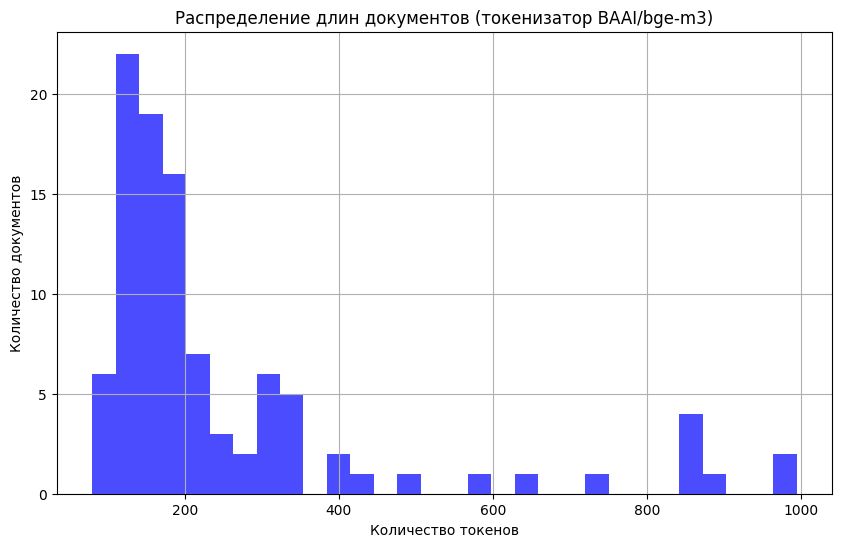

Максимальная длина: 994
Средняя длина: 256


In [ ]:
# Используем токенизатор от нашей модели эмбеддинга
tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)

# Считаем длину каждого документа в токенах
lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(RAW_KNOWLEDGE_BASE, desc="Подсчет токенов")]

# Рисуем график
plt.figure(figsize=(10, 6))
pd.Series(lengths).hist(bins=30, alpha=0.7, color='blue')
plt.title(f"Распределение длин документов (токенизатор {EMBEDDING_MODEL_NAME})")
plt.xlabel("Количество токенов")
plt.ylabel("Количество документов")
plt.show()

print(f"Максимальная длина: {max(lengths)}")
print(f"Средняя длина: {int(sum(lengths)/len(lengths))}")

**Анализ распределения токенов и стратегия чанкинга**
При выборе размера чанка (chunk_size) мы опираемся на два фактора:

1. **Длина документов:** Судя по графику распределения, средняя длина нашего гибридного документа составляет около 255 токенов.

2. **Специфика BGE-M3:** Эта мощная модель-энкодер поддерживает окно до 8192 токенов и демонстрирует наилучшее качество, когда «видит» весь семантический контекст целиком.

**Настройка сплиттера:** Поскольку наши документы уже предварительно агрегированы, жестко дробить их на мелкие куски не имеет смысла. Установим chunk_size = 512. Такой размер выбран «с запасом» — он гарантирует, что подавляющее большинство документов попадет в базу целиком, сохранив смысловую целостность.

In [ ]:
MARKDOWN_SEPARATORS = [
    "\n\n",  # Параграф
    "\n",    # Новая строка
    " ",     # Пробел
    "",
]

CHUNK_SIZE = 512

text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer,
    chunk_size=CHUNK_SIZE,       # большинство документов останутся целыми
    chunk_overlap=int(CHUNK_SIZE * 0.1),  # количество символов, которые будут перекрываться между чанками
    add_start_index=True,  # если "True", то включает начальный индекс чанка в метаданные
    strip_whitespace=True,  # если значение "True", то пробелы удаляются из начала и конца каждого документа
)

docs_processed = text_splitter.split_documents(RAW_KNOWLEDGE_BASE)

# Удаление дубликатов
unique_texts = set()
docs_processed_unique = []

for doc in docs_processed:
# Удалим дубликаты (если сплиттер создал идентичные куски)
    unique_id = f"{doc.metadata['place_id']}_{doc.page_content}"
 # Уникальность считаем по контенту + ID места, чтобы не склеить разные места с похожим описанием
    if unique_id not in unique_texts:
        unique_texts.add(unique_id)
        docs_processed_unique.append(doc)

print(f"Количество чанков после обработки: {len(docs_processed_unique)}")

Количество чанков после обработки: 123


**Создание векторного хранилища (Chroma)**

In [ ]:
EMBEDDING_MODEL = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=False,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},
)

In [ ]:
vector_db = Chroma.from_documents(
    documents=docs_processed_unique,
    embedding=EMBEDDING_MODEL,
    persist_directory=CHROMA_PATH, # Сохраняем на диск
    collection_name="tourism_rag"
)
print("База данных успешно создана и сохранена!")

База данных успешно создана и сохранена!


**Тестирование Ретривера**


Ищем по запросу: 'Какая главная достопримечательность в городе Владимир?'...

=================== TOP 1 RESULT ===================
Название: Ивановский вал
Город: Владимир
Координаты: 56.13422, 40.412052
Текст чанка: Объект: Ивановский вал
Локация: Владимир
Историческая справка: Влади́мир (др.-рус. Володимѣрь) — город в России, административный центр Владимирской области и городского округа город Владимир.
Исторически известен как Владимир-на-Клязьме или Владимир-Залесский, в отличие от Владимира-Волынского.
Существует две летописные версии основания города, в 990 и в 1108 году. Археологические изыскания, пров...
=== Ивановский вал (Владимир) ===
Всего фото (meta): 29
Тип данных: LIST (Pandas style)
Готово к отображению: 29 фото. Показываем первые 3...


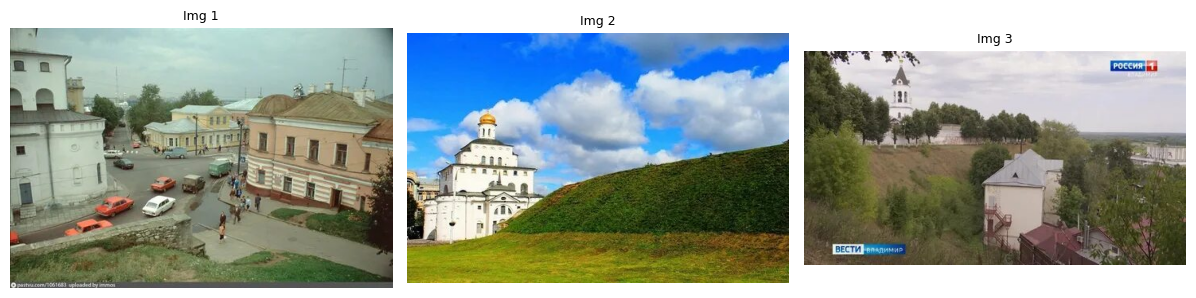

In [ ]:
# --- ЗАПУСК ПОИСКА ---
user_query = "Какая главная достопримечательность в городе Владимир?"

print(f"\nИщем по запросу: '{user_query}'...")

# Предполагается, что vector_db уже содержит ваши чанки (векторы)
retrieved_docs = vector_db.similarity_search(query=user_query, k=3)

# --- АНАЛИЗ TOP 1 ---
top_doc = retrieved_docs[0]
top_doc_name = top_doc.metadata.get('name')

print("\n=================== TOP 1 RESULT ===================")
print(f"Название: {top_doc_name}")
print(f"Город: {top_doc.metadata.get('city')}")
print(f"Координаты: {top_doc.metadata.get('lat')}, {top_doc.metadata.get('lon')}")
print(f"Текст чанка: {top_doc.page_content[:400]}...")
print("====================================================")
visualize_place_images_universal(rag_dataset, top_doc_name, max_images=3)

In [ ]:
%%time
user_query = "Что можно посмотреть в Ярославле?"
query_vector = EMBEDDING_MODEL.embed_query(user_query)
print(f"\nStarting retrieval for {user_query=}...")
retrieved_docs = vector_db.similarity_search(query=user_query, k=3)

print("\n==================================Топ похожих документов==================================")
for i in tqdm(range(len(retrieved_docs))):
    print(i, ' - '.join([retrieved_docs[i].page_content]))
    print('='*50)


Starting retrieval for user_query='Что можно посмотреть в Ярославле?'...

==================================Топ похожих документов==================================


  0%|          | 0/3 [00:00<?, ?it/s]

0 Объект: Музей занимательных наук Эйнштейна
Локация: Ярославль
Историческая справка: Яросла́вль — город в России, административный центр Ярославской области. Население 563 717 чел. (2025). Третий по численности населения город Центрального федерального округа Российской Федерации. Город является транспортным узлом, из которого расходятся железнодорожные линии и автодороги в направлении Москвы, Вологды, Рыбинска, Костромы, Иваново и Кирова. В Ярославле также действуют речной порт и аэропорт. Площадь города составляет 205 км².
Ярославль — один из старейших русских городов, основанный в XI веке и достигший своего расцвета в XVII веке; в 2010 году город отметил своё тысячелетие. День города в Ярославле обычно отмечается в последнюю субботу мая (в 2010 году в связи с тысячелетием города празднование проводилось с 10 по 12 сентября). Исторический центр города, расположенный у слияния рек Волги и Которосли, является объектом Всемирного наследия ЮНЕСКО. 
В административном отношении Ярославль

### Реранкер

In [ ]:
RERANKER = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")

artifact.metadata: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/405 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
print(f"\nStarting retrieval for {user_query=}...")
relevant_docs = [doc.page_content for doc in retrieved_docs]
relevant_docs = RERANKER.rerank(user_query, relevant_docs, k=3)

print("==================================Топ 1 проранжированный документ==================================")
print(relevant_docs[0])


Starting retrieval for user_query='Что можно посмотреть в Ярославле?'...


100%|██████████| 1/1 [00:00<00:00, 31.53it/s]


==================================Топ 1 проранжированный документ==================================
{'content': 'Объект: Приход Воздвижения Святого Креста (Ярославль)\nЛокация: Ярославль\nИсторическая справка: Яросла́вль — город в России, административный центр Ярославской области. Население 563 717 чел. (2025). Третий по численности населения город Центрального федерального округа Российской Федерации. Город является транспортным узлом, из которого расходятся железнодорожные линии и автодороги в направлении Москвы, Вологды, Рыбинска, Костромы, Иваново и Кирова. В Ярославле также действуют речной порт и аэропорт. Площадь города составляет 205 км².\nЯрославль — один из старейших русских городов, основанный в XI веке и достигший своего расцвета в XVII веке; в 2010 году город отметил своё тысячелетие. День города в Ярославле обычно отмечается в последнюю субботу мая (в 2010 году в связи с тысячелетием города празднование проводилось с 10 по 12 сентября). Исторический центр города, располо

### Визуализация поиска ближайших документов с помощью PCA и UMAP

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

**PCA**

In [ ]:
# Получение всех эмбеддингов чанков из векторной базы
documents_embeddings = vector_db.get(include=["embeddings"])['embeddings']
# 2. Объединение чанков и запроса для обучения PCA, добавляем эмбеддинг запроса в конец массива)
embeddings_array = np.array(documents_embeddings + [query_vector])
# Обучаем PCA на полном наборе (чанки + запрос) и трансформируем его
pca_emb = PCA(n_components=2, random_state=42)
documents_projected = pca_emb.fit_transform(embeddings_array)

print(f"Объясненная дисперсия первыми двумя компонентами PCA: {pca_emb.explained_variance_ratio_.sum():.2f}")

Объясненная дисперсия первыми двумя компонентами PCA: 0.16


In [ ]:
num_chunks = len(docs_processed_unique)
user_query = "Какая главная достпримечательность во Владимире?"
# Данные для чанков
df_chunks = pd.DataFrame.from_dict(
    [
        {
            "x": documents_projected[i, 0],
            "y": documents_projected[i, 1],
            "source": docs_processed_unique[i].metadata["city"],
            "extract": docs_processed_unique[i].page_content[:256] + "...",
            "symbol": "circle",
            "size_col": 4,
        }
        for i in range(num_chunks)
    ]
)

# Данные для запроса (это последняя точка в массиве documents_projected)
df_query = pd.DataFrame([
    {
        "x": documents_projected[-1, 0],
        "y": documents_projected[-1, 1],
        "source": "User query",
        "extract": user_query,
        "size_col": 30,
        "symbol": "star",
    }
])

# Объединение
df_pca = pd.concat([df_chunks, df_query], ignore_index=True)

# Визуализация эмбеддингов
fig = px.scatter(
    df_pca,
    x="x",
    y="y",
    color="source",
    hover_data="extract",
    size="size_col",
    symbol="symbol",
    color_discrete_map={"User query": "black"},
    width=1000,
    height=700,
)

fig.update_traces(
    marker=dict(opacity=1, line=dict(width=0, color="DarkSlateGrey")),
    selector=dict(mode="markers"),
)

fig.update_layout(
    legend_title_text="<b>Источник чанка</b>",
    title="<b>2D-проекция вложений чанка с помощью PCA</b>",
)
fig.show()

**Выводы по PCA-проекции:**

Объясненная дисперсия первых двух главных компонент составляет всего 16%. Это ожидаемо: эмбеддинги `BGE-M3` обладают огромной размерностью, а связи внутри них носят сложный, нелинейный характер. Линейный алгоритм PCA не может сжать их без потерь. Тем не менее, даже на этой грубой проекции видно, что вектор запроса попадает в релевантную область, что подтверждает работоспособность ретривера.

**UMAP**

In [ ]:
documents_embeddings = vector_db.get(include=["embeddings"])['embeddings']
embeddings_array = np.array(documents_embeddings + [query_vector])

umap_emb = umap.UMAP(
    n_components=2,
    n_neighbors=15,    # по умолчанию - 15
    min_dist=0.1,      # по умолчанию - 0.1
    random_state=42)

documents_projected = umap_emb.fit_transform(embeddings_array)

In [ ]:
num_chunks = len(docs_processed)

df_chunks = pd.DataFrame.from_dict(
    [
        {
            "x": documents_projected[i, 0],
            "y": documents_projected[i, 1],
            "source": docs_processed[i].metadata["city"], # Предполагаем, что порядок совпадает
            "extract": docs_processed[i].page_content[:256] + "...",
            "symbol": "circle",
            "size_col": 4,
        }
        for i in range(num_chunks)
    ]
)

df_query = pd.DataFrame([
    {
        "x": documents_projected[-1, 0],
        "y": documents_projected[-1, 1],
        "source": "User query",
        "extract": user_query,
        "size_col": 30,
        "symbol": "star",
    }
])

df_umap = pd.concat([df_chunks, df_query], ignore_index=True)

fig = px.scatter(
    df_umap,
    x="x",
    y="y",
    color="source",
    hover_data="extract",
    size="size_col",
    symbol="symbol",
    color_discrete_map={"User query": "black"},
    width=1000,
    height=700,
)

fig.update_traces(
    marker=dict(opacity=1, line=dict(width=0, color="DarkSlateGrey")),
    selector=dict(mode="markers"),
)

fig.update_layout(
    legend_title_text="<b>Источник чанка</b>",
    title="<b>2D-проекция вложений чанка с помощью UMAP</b>",
)
fig.show()

**Выводы по UMAP-проекции:**

Нелинейный алгоритм `UMAP` справился с задачей снижения размерности превосходно:
- Векторы отчетливо сгруппировались в плотные, хорошо различимые кластеры, соответствующие разным городам.
- Точка пользовательского запроса (отмечена звездой) легла точно внутрь большого целевого кластера (Владимир). Это визуально доказывает высокую точность семантического поиска в нашей базе.

 ### Reader

Для роли интеллектуального гида будем использовать модель `Qwen2.5-1.5B-Instruct`. Её контекстное окно составляет $2048$ токенов.
Проведем расчет: мы извлекаем топ-3 релевантных документа (максимум по 512 токенов каждый). Это займет ≈1536 токенов. Оставшихся ≈500 токенов с запасом хватит на системный промпт, вопрос пользователя и генерацию ответа.

---
Для экономии видеопамяти (VRAM) загрузим веса модели в 4-битной квантизации, при этом вычисления на прямом проходе (forward pass) будут производиться в формате `bf16`.


In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

MODELLLM = AutoModelForCausalLM.from_pretrained(MODEL_NAME,
                                                quantization_config=bnb_config)

TOKENIZER = AutoTokenizer.from_pretrained(MODEL_NAME)

READER_LLM = pipeline(
    model=MODELLLM,
    tokenizer=TOKENIZER,
    task="text-generation",
    do_sample=True,
    temperature=0.2,
    repetition_penalty=1.1,
    return_full_text=False,
    max_new_tokens=550)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


### Формирование системного промпта

Ниже представлен RAG-шаблон, который мы передадим в Reader LLM. Крайне важно пропустить его через метод `apply_chat_template` токенизатора Qwen, чтобы модель корректно распознала роли. В промпте мы жестко задаем поведение модели: она должна отвечать на вопросы пользователя, опираясь исключительно на подгруженный контекст, избегая любых галлюцинаций.

In [ ]:
prompt_in_chat_format = [
    {
        "role": "system",
        "content": """Ты виртуальный туристический гид по городам России.
Твоя задача — помогать туристам узнать о достопримечательностях, истории и культуре городов.

Правила ответа:
1. Используй ТОЛЬКО информацию из предоставленного контекста
2. Если в контексте несколько мест — кратко опиши каждое
3. Если контекст не содержит ответа, честно скажи: "К сожалению, у меня нет информации об этом"
4. Пиши дружелюбно и информативно, как настоящий гид
5. Избегай выдумок — только факты из контекста""",
    },
    {
        "role": "user",
        "content": """Контекст с информацией о достопримечательностях:
{context}

---
Вопрос туриста: {question}

Ответ:""",
    },
]

RAG_PROMPT_TEMPLATE = TOKENIZER.apply_chat_template(
    prompt_in_chat_format, tokenize=False, add_generation_prompt=True
)
print(RAG_PROMPT_TEMPLATE)

<|im_start|>system
Ты виртуальный туристический гид по городам России.
Твоя задача — помогать туристам узнать о достопримечательностях, истории и культуре городов.

Правила ответа:
1. Используй ТОЛЬКО информацию из предоставленного контекста
2. Если в контексте несколько мест — кратко опиши каждое
3. Если контекст не содержит ответа, честно скажи: "К сожалению, у меня нет информации об этом"
4. Пиши дружелюбно и информативно, как настоящий гид
5. Избегай выдумок — только факты из контекста<|im_end|>
<|im_start|>user
Контекст с информацией о достопримечательностях:
{context}

---
Вопрос туриста: {question}

Ответ:<|im_end|>
<|im_start|>assistant



**Тестирование LLM Reader**

In [ ]:
retrieved_docs = vector_db.similarity_search(query=user_query, k=5)
retrieved_context = "\n\n".join([doc.page_content for doc in retrieved_docs])
user_query = "Какие храмы есть во Владимире?"
# Заполняем шаблон контекстом и вопросом
final_prompt = RAG_PROMPT_TEMPLATE.format(
    context=retrieved_context,
    question=user_query
)

response = READER_LLM(final_prompt)
generated_answer = response[0]['generated_text'].strip()

print("\n--- ГЕНЕРИРУЕМЫЙ ОТВЕТ ---")
print(generated_answer)
print("---------------------------------------")


--- ГЕНЕРИРУЕМЫЙ ОТВЕТ ---
Владимир - это исторический и культурный центр России, где множество храмов и церквей. Вот некоторые из них:

1. **Церковь Святой Троицы** - это старообрядческий храм, который был построен в 1913-1916 годах. Он является памятником архитектуры регионального значения и находится в центре города. 

2. **Успенский собор** - один из самых старых соборов в городе, построенный в XII-XIV веках. Это место для молитвы и службы.

3. **Дмитриевский собор** - еще один древний собор, построенный в XIII-XIV веках. Этот собор также служит местом для молитвы и службы.

4. **Успенский собор** - еще один древний собор, построен в XII-XIV веках. Этот собор также служит местом для молитвы и службы.

Эти храмы и церкви играют важную роль в культурной жизни города и являются одними из главных достопримечательностей.
---------------------------------------


### Финальный RAG-Pipeline

In [ ]:
import copy
NUM_CHUNKS_FINAL = 4

def answer_with_rag(
    question: str,
    llm: Pipeline,
    knowledge_index,  # ChromaDB retriever
    tokenizer,
    rag_prompt_template: List[dict],
    reranker,
    num_retrieved_docs: int = 10,   # Извлекаем с запасом для реранкера
) -> Tuple[str, List[LangchainDocument]]:

    # RETRIEVAL (Поиск)
    print(f"=> Retrieving documents for: '{question}'...")

    # Chroma возвращает список объектов LangchainDocument
    initial_docs = knowledge_index.similarity_search(query=question, k=num_retrieved_docs)

    # RERANKING
    final_docs = []

    if reranker:
        print("=> Reranking documents...")
        doc_texts = [d.page_content for d in initial_docs]
        # RAGatouille  возвращает список словарей [{'content':..., 'score':..., 'result_index':...}]
        reranked_results = reranker.rerank(query=question, documents=doc_texts, k=4)
        # Восстанавливаем объекты LangchainDocument по индексам (чтобы сохранить метаданные!)
        for result in reranked_results:
            original_idx = result['result_index'] # Индекс в initial_docs
            doc = initial_docs[original_idx]
            # Можно добавить score от реранкера в метаданные
            doc.metadata['rerank_score'] = result['score']
            final_docs.append(doc)

    else:
        # Если реранкера нет, просто берем топ-3 самых похожих по косинусу
        final_docs = initial_docs[:NUM_CHUNKS_FINAL]

    # CONTEXT AGGREGATION
    context_text = ""
    for i, doc in enumerate(final_docs):
        # Добавляем разделитель, чтобы модель видела границы документов
        context_text += f"Документ {i+1}:\n{doc.page_content}\n\n"

    # PROMPT ENGINEERING
    # Делаем глубокую копию шаблона, чтобы не испортить оригинал для следующих запросов
    messages = copy.deepcopy(rag_prompt_template)

    # Находим сообщение пользователя и форматируем его
    for message in messages:
        if message['role'] == 'user':
            message['content'] = message['content'].format(
                context=context_text,
                question=question
            )
            break

    # Превращаем список словарей в одну строку с токенами <|im_start|> и т.д.
    final_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # GENERATION
    print("=> Generating answer...")

    outputs = llm(
        final_prompt,
        max_new_tokens=400, # Ограничиваем, чтобы не вылететь за 2k (остаток около 500)
        return_full_text=False # Возвращаем только ответ ассистента
    )

    answer_text = outputs[0]["generated_text"].strip()

    return answer_text, final_docs

In [ ]:
answer, sources = answer_with_rag(
    question="Где можно погулять во Владимире?",
    llm=READER_LLM,
    knowledge_index=vector_db,
    tokenizer=TOKENIZER,
    rag_prompt_template=prompt_in_chat_format,
    reranker=RERANKER # Пока None, если RAGatouille не заработал
)

print("\n" + "="*40)
print(f"ОТВЕТ ГИДА:\n{answer}")
print("="*40)
print("Источники:")
for doc in sources:
    print(f"- {doc.metadata.get('name')} ({doc.metadata.get('city')})")

=> Retrieving documents for: 'Где можно погулять во Владимире?'...
=> Reranking documents...


100%|██████████| 1/1 [00:00<00:00, 10.49it/s]


=> Generating answer...

ОТВЕТ ГИДА:
Владимир - это одно из самых популярных туристических центров в Европе. Здесь есть множество достопримечательностей, таких как Владимирское духовное училище, Ивановский вал и Владимиро-Суздальский музей-заповедник. Вы можете прогуляться по главному проспекту, который проходит через весь город, или посмотреть старинную церковь на горе. Также стоит посетить Владимирский областной театр кукол для того, чтобы увидеть живописные работы масштаба.
Источники:
- Владимирское духовное училище (Владимир)
- Ивановский вал (Владимир)
- Владимиро-Суздальский музей-заповедник (центральный офис) (Владимир)
- Владимирский областной театр кукол (Владимир)


**Красивый вывод с фото и геолокациями достопримечательностей**

In [ ]:
METADATA_DELIMITER = " ||| "

def visualize_doc_images(sources: List[LangchainDocument], max_images_per_doc: int = 2):
    """
    Визуализирует изображения для каждого источника, извлеченного RAG-системой.
    """
    all_images_to_show = []

    for idx, doc in enumerate(sources):
        raw_data = doc.metadata.get('images_meta')

        b64_list = []
        if isinstance(raw_data, str) and raw_data.strip():
            # Это строка (ChromaDB формат)
            b64_list = raw_data.split(METADATA_DELIMITER)
        elif isinstance(raw_data, list):
            # Это список (Pandas/оригинальный формат)
            b64_list = raw_data

        # Фильтруем пустые и неполные строки
        b64_list = [x for x in b64_list if x and len(str(x)) > 100]

        if not b64_list:
            print(f"[{doc.metadata.get('name', 'N/A')}] Фото не найдены в метаданных.")
            continue

        images_to_show = b64_list[:max_images_per_doc]

        for i, b64_string in enumerate(images_to_show):
            try:
                clean_b64 = str(b64_string).strip("b'").strip("'")
                image_data = base64.b64decode(clean_b64)
                image = Image.open(io.BytesIO(image_data))

                all_images_to_show.append({
                    'title': f"Док. {idx+1}: {doc.metadata.get('name')}",
                    'image': image
                })
            except Exception as e:
                print(f"Ошибка декодирования фото {i+1} для {doc.metadata.get('name')}. Ошибка: {e}")

    # Построение общей галереи
    if not all_images_to_show:
        return

    num_images = len(all_images_to_show)
    cols = min(4, num_images)
    rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(20, 4 * rows))
    plt.suptitle("Изображения из извлеченного контекста", fontsize=16)

    for i, item in enumerate(all_images_to_show):
        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(item['image'])
        plt.axis('off')
        plt.title(item['title'], fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def execute_rag_query(question: str):
    """
    Выполняет RAG-запрос, печатает ответ и выводит метаданные с фотографиями.
    """
    try:
        answer, sources = answer_with_rag(
            question=question,
            llm=READER_LLM,
            knowledge_index=vector_db, # Ваша база Chroma/FAISS
            tokenizer=TOKENIZER,
            rag_prompt_template=prompt_in_chat_format,
            reranker=None # Или ваш инициализированный reranker
        )
    except Exception as e:
        print(f"\nКритическая ошибка при выполнении RAG-пайплайна: {e}")
        return

    print("\n" + "="*60)
    print(f"ВОПРОС: {question}")
    print("="*60)
    print(f"ОТВЕТ ТУРИСТИЧЕСКОГО ГИДА:\n{answer}")
    print("="*60)

    print("Источники и Метаданные:")
    for i, doc in enumerate(sources):
        name = doc.metadata.get('name', 'N/A')
        city = doc.metadata.get('city', 'N/A')
        lat = doc.metadata.get('lat')
        lon = doc.metadata.get('lon')

        geo_info = "Геолокация: N/A"
        if lat is not None and lon is not None:
            geo_info = f"📍 Геолокация: {lat:.4f}, {lon:.4f}"

        print(f"\n--- ДОКУМЕНТ {i+1} ---")
        print(f"Название: {name} ({city})")
        print(f"{geo_info}")
        print(f"Фрагмент текста: {doc.page_content[:150]}...")

    visualize_doc_images(sources, max_images_per_doc=2)

=> Retrieving documents for: 'Где можно погулять во Владимире?'...
=> Generating answer...

ВОПРОС: Где можно погулять во Владимире?
ОТВЕТ ТУРИСТИЧЕСКОГО ГИДА:
Владимир - один из самых популярных туристических центров в Европе. Здесь есть множество достопримечательностей, таких как Владимирское духовное училище, Владимирский областной театр кукол и Ивановский вал. Также стоит обратить внимание на Князь-Владимирское кладбище, которое находится на Большой Нижегородской улице. Если вам интересно прогуляться, я бы рекомендовал посетить Владимирский областной театр кукол. Этот объект особенно популярен среди туристов, так как он расположен в историческом районе города. Кроме того, если вы хотите расслабиться после тяжёлых экскурсий, вы можете посетить Владимирское духовное училище, где вас ждут красивые интерьеры и богатая история.
Источники и Метаданные:

--- ДОКУМЕНТ 1 ---
Название: Владимирское духовное училище (Владимир)
📍 Геолокация: 56.1366, 40.4110
Фрагмент текста: Объект: Владимирск

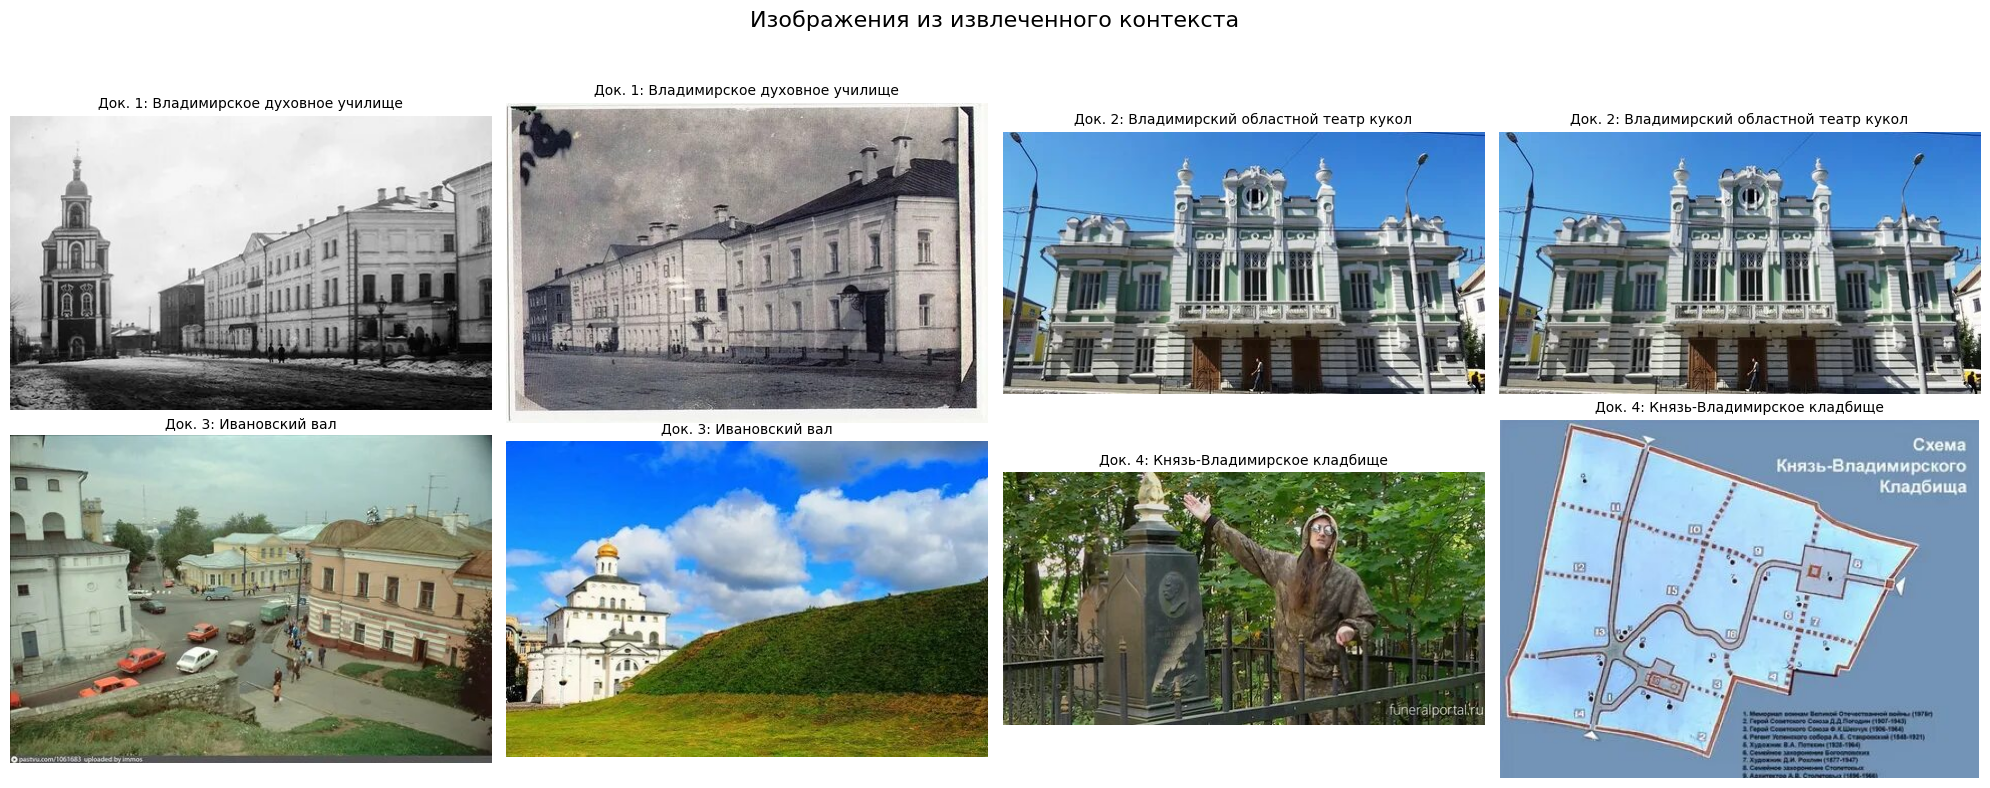

In [ ]:
execute_rag_query(question="Где можно погулять во Владимире?")

=> Retrieving documents for: 'Где можно погулять во Ярославле?'...
=> Generating answer...

ВОПРОС: Где можно погулять во Ярославле?
ОТВЕТ ТУРИСТИЧЕСКОГО ГИДА:
В Ярославле есть множество интересных мест, где можно погулять. Одним из таких мест является Воинское мемориальное кладбище. Это место идеально подходит для прогулок, так как там много белых гранита, создавая красивый фон для прогулок. Также стоит обратить внимание на исторический центр города, который расположен у слияния рек Волги и Которосли. Здесь можно посетить множество достопримечательностей, среди которых Церковь Николая Надеина, которая имеет уникальное стилизованное оконное остекление. Кроме того, если вы любите вкусить местную еду, вам понравится Приход Воздвижения Святого Креста, где можно попробовать местные блюда. Вокруг этих мест располагаются парки и набережные, что делает прогулку еще более приятной.
Источники и Метаданные:

--- ДОКУМЕНТ 1 ---
Название: Музей занимательных наук Эйнштейна (Ярославль)
📍 Геолокация

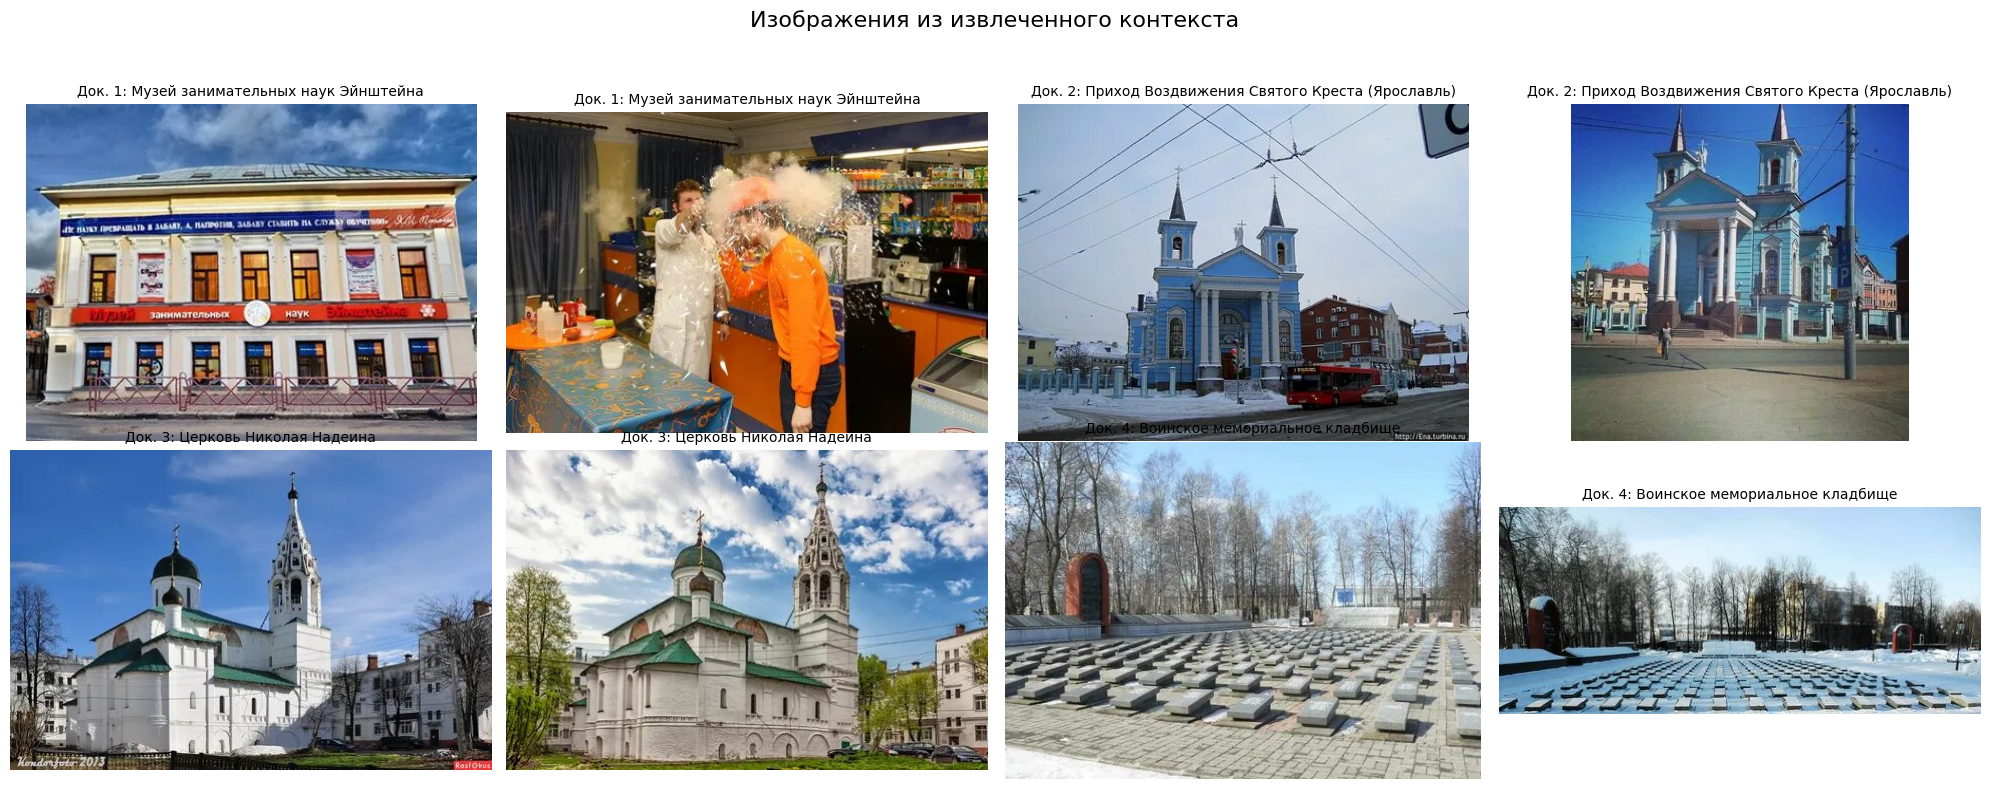

In [ ]:
execute_rag_query(question="Где можно погулять во Ярославле?")

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

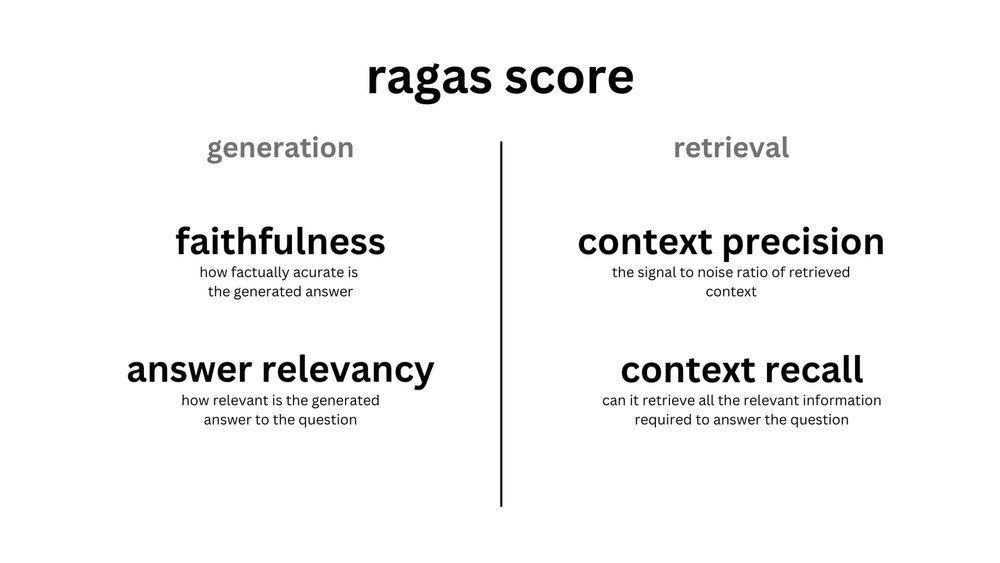

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [ ]:
import torch
from tqdm.auto import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

**Генерация тестового датасета (Синтетические данные)**:

Для оценки качества RAG-системы нам нужен набор данных с эталонными вопросами и ответами. Создадим функцию-генератор со следующей логикой:
- спользуя LLM (подход Reverse Engineering), функция будет читать извлеченные документы и автоматически генерировать к ним пару: "Вопрос" + "Правильный ответ (`ground_truth`)".
- Для экономии времени на инференс и расчет метрик, размер тестовой выборки ограничим 50 случайными документами из базы.

In [ ]:
EVAL_MODEL_NAME = "BAAI/bge-m3"
eval_emb_model = SentenceTransformer(EVAL_MODEL_NAME)

def data_preprocess(documents, llm_pipeline, tokenizer, n_samples=50, seed=42):
    """
    Генерирует синтетический датасет (Question, Ground Truth) с помощью LLM.
    """
    import random
    random.seed(seed)

    # Берем случайные документы из базы
    if hasattr(documents, 'to_list'): # Если это Series/DataFrame
        docs_list = documents.to_list()
    else:
        docs_list = documents

    selected_docs = random.sample(docs_list, min(len(docs_list), n_samples))

    data = []
    print(f"Генерация {len(selected_docs)} вопросов с помощью LLM...")

    for doc in tqdm(selected_docs):
        # Если doc - это LangChain Document
        text = doc.page_content[:1000] if hasattr(doc, 'page_content') else str(doc)[:1000]

        # Промпт для генерации
        prompt = [
            {"role": "system", "content": "Придумай один вопрос на русском языке к этому тексту и напиши правильный ответ."},
            {"role": "user", "content": f"Текст: {text}\n\nФормат:\nВопрос: ...\nОтвет: ..."}
        ]

        # Генерация
        prompt_str = tokenizer.apply_chat_template(prompt, tokenize=False, add_generation_prompt=True)
        try:
            output = llm_pipeline(prompt_str, max_new_tokens=300, return_full_text=False)[0]['generated_text']

            # Парсинг
            if "Вопрос:" in output and "Ответ:" in output:
                parts = output.split("Ответ:")
                q = parts[0].replace("Вопрос:", "").strip()
                gt = parts[1].strip()
                data.append({
                    "question": q,
                    "ground_truth": gt,
                    "original_text": text
                })
        except Exception as e:
            print(f"Ошибка генерации: {e}")
            continue

    return pd.DataFrame(data)

**Автоматическое тестирование RAG-пайплайна**
Далее реализуем функцию для прогона нашего синтетического датасета через созданную поисковую систему.
- В основе лежит ранее написанная функция пайплайна `answer_with_rag`
- Функция автоматически задаст все 50 сгенерированных вопросов нашей RAG-системе, запишет ответы LLM и сохранит извлеченные контексты для последующего сравнения с `ground_truth`.

In [ ]:
def get_rag_answers(test_df, rag_function, **kwargs):
    """
    Прогоняет вопросы через RAG и сохраняет ответы и контексты.
    """
    answers = []
    contexts = []

    print("Запуск RAG инференса...")
    for q in tqdm(test_df['question']):
        try:
            # Вызов функции RAG-pipeline
            ans, source_docs = rag_function(question=q, **kwargs)
            answers.append(ans)
            # Сохраняем тексты найденных документов
            contexts.append([d.page_content for d in source_docs])
        except Exception as e:
            print(f"Ошибка RAG: {e}")
            answers.append("")
            contexts.append([])

    test_df['answer'] = answers
    test_df['contexts'] = contexts
    return test_df

In [ ]:
def answer_relevancy_custom(df, llm_pipeline, tokenizer, embedding_model):
    """
    Кастомная реализация Answer Relevancy по алгоритму RAGAS:
    1. Генерируем вопросы (Reverse Engineering) на основе ответа.
    2. Считаем сosine similarity между оригинальным вопросом и сгенерированными.
    """
    relevancy_scores = []

    print("Расчет Answer Relevancy...")
    for i, row in tqdm(df.iterrows(), total=len(df)):
        answer = row['answer']
        original_question = row['question']

        if not answer or len(answer) < 5:
            relevancy_scores.append(0.0)
            continue

        # генерируем вопрос по ответу
        prompt = [
            {"role": "system", "content": "Сгенерируй вопрос на русском языке, для которого данный текст является идеальным ответом."},
            {"role": "user", "content": f"Ответ: {answer}\n\nВопрос:"}
        ]
        prompt_str = tokenizer.apply_chat_template(prompt, tokenize=False, add_generation_prompt=True)

        try:
            generated_question = llm_pipeline(prompt_str, max_new_tokens=300, return_full_text=False)[0]['generated_text'].strip()

            # Считаем сходство векторов
            # вектор оригинального вопроса
            orig_emb = embedding_model.encode(original_question, convert_to_tensor=True)
            # вектор сгенерированного вопроса
            gen_emb = embedding_model.encode(generated_question, convert_to_tensor=True)

            # Cosine Similarity
            # приводим к numpy для sklearn или используем torch
            score = cosine_similarity(
                orig_emb.cpu().numpy().reshape(1, -1),
                gen_emb.cpu().numpy().reshape(1, -1)
            )[0][0]

            relevancy_scores.append(score)

        except Exception as e:
            print(f"Ошибка при расчете метрики: {e}")
            relevancy_scores.append(0.0)

    # среднее по датасету
    return sum(relevancy_scores) / len(relevancy_scores)

# Протестируйте ваш RAG (3 балла)

In [ ]:
test_dataset = data_preprocess(
    documents=docs_processed_unique,
    llm_pipeline=READER_LLM,
    tokenizer=TOKENIZER,
    n_samples=50
)

Генерация 50 вопросов с помощью LLM...


  0%|          | 0/50 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
test_dataset.sample(2)

,question,ground_truth,original_text
30,Какое название усадьбы принадлежит семье Расто...,Усадьба Расторгуевых принадлежит семье Харитон...,Объект: Усадьба Расторгуевых — Харитоновых\nЛо...
34,Какая библиотечная лужайка находится в городе ...,Великий Устюг,Объект: Библиотечная лужайка\nЛокация: Владими...


In [ ]:
rag_results = get_rag_answers(
    test_dataset,
    answer_with_rag,
    # Аргументы для вашей функции:
    llm=READER_LLM,
    knowledge_index=vector_db,
    tokenizer=TOKENIZER,
    rag_prompt_template=prompt_in_chat_format,
    reranker=RERANKER
)

Запуск RAG инференса...


  0%|          | 0/50 [00:00<?, ?it/s]

=> Retrieving documents for: 'Какая церковь находится в Ярославле?'...
=> Reranking documents...



100%|██████████| 1/1 [00:00<00:00, 10.46it/s]

=> Generating answer...


...


100%|██████████| 1/1 [00:00<00:00, 19.68it/s]

=> Generating answer...


=> Retrieving documents for: 'Какое значение имеет город Нижний Новгород для России?'...
=> Reranking documents...
WARNING! Your documents have duplicate entries!  This will slow down calculation and may yield subpar results



100%|██████████| 1/1 [00:00<00:00, 16.51it/s]

=> Generating answer...


In [ ]:
rag_results.sample(2)

,question,ground_truth,original_text,answer,contexts
2,"Как называется театр, который был основан в 19...",Театр оперы и балета имени А. С. Пушкина.,Объект: Театр оперы и балета\nЛокация: Нижний ...,"Театр, который был основан в 1935 году как Гор...",[Объект: Театр оперы и балета\nЛокация: Нижний...
41,Какая планета изображена на этом海报е?,Это Венера.,Объект: Венера\nЛокация: Владимир\nИсторическа...,На этом海报е изображен планета Венера.,[Объект: Собор Архангела Михаила\nЛокация: Ниж...


In [ ]:
ar_score = answer_relevancy_custom(
    rag_results,
    READER_LLM,
    TOKENIZER,
    eval_emb_model
)

Расчет Answer Relevancy...


  0%|          | 0/50 [00:00<?, ?it/s]

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

**Кастомная функция `context_recall_custom`** вычисляет, какая доля слов из правильного ответа (Ground Truth) была найдена в контексте, который RAG-система использовала для генерации ответа.
Расчет: Вычисляется Recall по формуле:$$  \text{Recall} = \frac{\text{|Токены GT, найденные в Контексте|}}{\text{|Все токены GT|}}$$

In [ ]:
from typing import Callable, Set

def context_recall_custom(df, tokenizer_func: Callable[[str], List[str]]) -> float:
    """
    Считает метрику Context Recall на основе пересечения токенов
    между Ground Truth и найденным Context.
    Эта реализация основана на сравнении множеств токенов (Word Overlap).
    """
    scores = []

    print("Расчет Context Recall (по токенам)...")

    for i, row in tqdm(df.iterrows(), total=len(df)):
        gt: str = row['ground_truth']
        # 'contexts' — это List[str], объединяем в одну строку
        context_list: List[str] = row['contexts']
        context_text: str = " ".join(context_list)

        # токенизация и создание множеств, использование set() ускоряет операции пересечения (Intersection)
        gt_tokens: Set[str] = set(tokenizer_func(gt))
        context_tokens: Set[str] = set(tokenizer_func(context_text))

        # обработка пустого GT (чтобы избежать деления на ноль)
        if not gt_tokens:
            scores.append(0.0)
            continue

        # расчет Recall, пересечение: Токены из GT, которые были найдены в контексте
        intersection: Set[str] = gt_tokens.intersection(context_tokens)

        # формула Recall: |Токены GT, найденные в контексте| / |Все токены GT|
        recall: float = len(intersection) / len(gt_tokens)
        scores.append(recall)

    # возвращаем средний recall по всем наблюдениям
    return sum(scores) / len(scores)

In [ ]:
cr_score = context_recall_custom(
    df=rag_results,
    tokenizer_func=TOKENIZER.tokenize)
print(f"Context Recall (Custom): {cr_score:.4f}")

Расчет Context Recall (по токенам)...


  0%|          | 0/50 [00:00<?, ?it/s]

Context Recall (Custom): 0.7311


In [ ]:
print(f"\n================ РЕЗУЛЬТАТЫ ================")
print(f"Answer Relevancy: {ar_score:.4f}")
print(f"Context Recall:   {cr_score:.4f}")
print("============================================")


================ РЕЗУЛЬТАТЫ ================
Answer Relevancy: 0.7072
Context Recall:   0.7311


---

## Выводы по работе RAG-системы

---

### 1. Анализ и Подготовка Данных (EDA & Обогащение)

| Аспект | Краткий вывод |
| :--- | :--- |
| **Проблемы данных** | Исходный датасет содержал $\approx 17.5\%$ пропусков в ключевых метаданных. Базовые русскоязычные описания оказались неинформативными, что потребовало обязательного **внешнего обогащения** фактами. |
| **Очистка/Агрегация** |  Разрозненные медиа-данные ($\approx14.6\%$ тыс. строк) успешно сгруппированы в 391 уникальный объект по ключу `place_id`. Для тестирования пайплайна сформирована чистая база знаний, включающая **100 целевых достопримечательностей**. |
| **Обогащение** | Сформирован **гибридный контекст**, объединяющий текстовую и визуальную модальности: **исторические справки** (парсинг Wikipedia) и **визуальные описания** изображений (сгенерированные моделью BLIP). |

***

### 2. Настройка RAG-Пайплайна

| Компонент | Выбор / Параметры | Результат |
| :--- | :--- | :--- |
| **Эмбеддер** | **BGE-M3** | Выбрана мощная мультиязычная модель (необходима для работы со смешанным RU/EN контекстом). Обладает контекстным окном 8k+ и высокой точностью построения семантических пространств. |
| **Векторная база** | **ChromaDB** | Оптимальное решение для быстрого локального хранения эмбеддингов и эффективного векторного поиска. |
| **LLM (Reader)** | **Qwen 1.5B-Instruct** | Компактная, но мощная модель. Отличается высокой скоростью инференса и строгим следованием инструкциям. Ограничение окна в токенов учтено при архитектуре пайплайна. |
| **Чанкинг** | $\text{CHUNK_SIZE} = 512$ | Разбиение с перекрытием (overlap) с перекрытием $50$ токенов. Увеличенный размер чанка выбран намеренно для сохранения максимальной семантической целостности каждого документа. |
| **Ретривер (k)** | $k=3$ | Количество извлекаемых документов строго ограничено, чтобы итоговый объем промпта с контекстом гарантированно помещался в лимит окна генеративной модели. |
| **Реранкер** | **RAGatouille** (ColBERT) | Внедрен для повышения итоговой релевантности поиска (Advanced RAG). Модель отбирает топ-3 лучших документа из расширенной первичной выборки ($k=10$). |

***

### 3. Генерация и Оценка (RAGAS)

| Аспект | Краткий вывод |
| :--- | :--- |
| **Промптинг** | Использован **строгий системный промпт** (с использованием Chat Template). Модели задана роль «туристического гида» с жестким ограничением **опираться ИСКЛЮЧИТЕЛЬНО на предоставленный контекст** для предотвращения галлюцинаций. |
| **Метрики** | Реализованы две кастомные метрики: **Answer Relevancy** (оценка косинусного сходства между оригинальным запросом и сгенерированным путем Reverse Engineering) и **Context Recall** (оценка полноты контекста через Word Overlap / пересечение токенов с Ground Truth). |
